In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 100)

In [2]:
df = pd.read_csv("raw_jobs.csv")
df.head()

,job_id,job_title,company,location,salary_min,salary_max,description,job_url,created,search_role
0,5867270220,Data Scientist,EXL,India,NaN,NaN,"Advanced Analytics & Data Science Execution: Lead high-impact AI and data science projects, incl...",https://www.adzuna.in/land/ad/5867270220?se=DNBW6Iqx8RGzHbodtesYlg&utm_medium=api&utm_source=673...,2026-09-02T21:46:18Z,Data Scientist
1,5876010793,Data Scientist,Infosys Finacle,"Bangalore, Karnataka",NaN,NaN,Job Title: Data Scientist and Senior Data Scientist / AI & Machine Learning Engineer Experience ...,https://www.adzuna.in/land/ad/5876010793?se=DNBW6Iqx8RGzHbodtesYlg&utm_medium=api&utm_source=673...,2026-09-09T00:59:08Z,Data Scientist
2,5870857421,Data Scientist,Tata Consultancy Services,"Bangalore, Karnataka",NaN,NaN,TCS has been a great pioneer in feeding the fire of Young Techies like you. We are a global lead...,https://www.adzuna.in/land/ad/5870857421?se=DNBW6Iqx8RGzHbodtesYlg&utm_medium=api&utm_source=673...,2026-09-04T22:28:36Z,Data Scientist
3,5864436644,Data Scientist,Atain,India,NaN,NaN,Data Scientist Location: Remote – India Experience: 7 Years Employment Type: Full-Time Role Over...,https://www.adzuna.in/land/ad/5864436644?se=DNBW6Iqx8RGzHbodtesYlg&utm_medium=api&utm_source=673...,2026-09-01T16:22:31Z,Data Scientist
4,5864424453,Data Scientist,AB InBev GCC India,"Bangalore, Karnataka",NaN,NaN,Dreaming big is in our DNA. It’s who we are as a company. It’s our culture. It’s our heritage. A...,https://www.adzuna.in/land/ad/5864424453?se=DNBW6Iqx8RGzHbodtesYlg&utm_medium=api&utm_source=673...,2026-09-01T16:20:22Z,Data Scientist


In [3]:
print("Shape:", df.shape)

Shape: (12145, 10)


In [4]:
df.tail()

,job_id,job_title,company,location,salary_min,salary_max,description,job_url,created,search_role
12140,5039639939,network solutions Architect,Kiara Global Services,"Pune, Maharashtra",800000.0,1000000.0,"network automation tools Ansible terraform D wan cloud networking (Aws,AzurE,Gcp) desinging netw...",https://www.adzuna.in/details/5039639939?utm_medium=api&utm_source=67334a16,2025-02-06T13:33:52Z,Solutions Architect
12141,2853928242,Cloud Solutions Architect,Multi Recruit,"Mumbai, Maharashtra",2000000.0,2500000.0,"Key Skills: AWS Cloud, CICD, Serverless setups, Monitoring Setup Performance setup, scalability ...",https://www.adzuna.in/details/2853928242?utm_medium=api&utm_source=67334a16,2022-01-30T04:34:31Z,Solutions Architect
12142,5120360659,Cloud Solution Architect,BackToIndia,"Bangalore, Karnataka",NaN,NaN,"Develop Cloud solutions, support sales teams, perform opportunity triage and sales support liais...",https://www.adzuna.in/details/5120360659?utm_medium=api&utm_source=67334a16,2025-04-01T01:32:02Z,Solutions Architect
12143,5416720075,Senior Solution Architect,Recruit Square,India,1500000.0,2300000.0,Key Responsibilities 1. Platform & Application Architecture Architect and oversee end-to-end pla...,https://www.adzuna.in/details/5416720075?utm_medium=api&utm_source=67334a16,2025-09-27T07:19:39Z,Solutions Architect
12144,5800395036,IT Solution Architect,Nokia Global,India,NaN,NaN,"Description We are seeking a highly skilled and experienced Network Routing Architect to design,...",https://www.adzuna.in/details/5800395036?utm_medium=api&utm_source=67334a16,2026-07-15T03:23:43Z,Solutions Architect


In [23]:
df = df.drop(columns=[
    "job_id",
    "salary_min",
    "salary_max",
    "job_url"
], errors="ignore")

In [24]:
print("Duplicates before:", df.duplicated().sum())

df = df.drop_duplicates().reset_index(drop=True)

print("Duplicates after:", df.duplicated().sum())
print("Shape:", df.shape)

Duplicates before: 22
Duplicates after: 0
Shape: (12119, 6)


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12119 entries, 0 to 12118
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   job_title    12119 non-null  object
 1   company      11994 non-null  object
 2   location     12119 non-null  object
 3   description  12119 non-null  object
 4   created      12119 non-null  object
 5   search_role  12119 non-null  object
dtypes: object(6)
memory usage: 568.2+ KB


In [26]:
df.isnull().sum()

job_title        0
company        125
location         0
description      0
created          0
search_role      0
dtype: int64

In [27]:
missing = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": (
        df.isnull().sum() / len(df) * 100
    ).round(2)
})

missing.sort_values("Missing_Percentage", ascending=False)

,Missing_Count,Missing_Percentage
company,125,1.03
job_title,0,0.00
location,0,0.00
description,0,0.00
created,0,0.00
search_role,0,0.00


In [28]:
for col in df.columns:
    print(f"\n{'='*60}")
    print(f"Column: {col}")
    print(f"Unique values: {df[col].nunique()}")
    print(df[col].head(5))


Column: job_title
Unique values: 4446
0    Data Scientist
1    Data Scientist
2    Data Scientist
3    Data Scientist
4    Data Scientist
Name: job_title, dtype: object

Column: company
Unique values: 4693
0                          EXL
1              Infosys Finacle
2    Tata Consultancy Services
3                        Atain
4           AB InBev GCC India
Name: company, dtype: object

Column: location
Unique values: 192
0                   India
1    Bangalore, Karnataka
2    Bangalore, Karnataka
3                   India
4    Bangalore, Karnataka
Name: location, dtype: object

Column: description
Unique values: 9613
0    Advanced Analytics & Data Science Execution: Lead high-impact AI and data science projects, incl...
1    Job Title: Data Scientist and Senior Data Scientist / AI & Machine Learning Engineer Experience ...
2    TCS has been a great pioneer in feeding the fire of Young Techies like you. We are a global lead...
3    Data Scientist Location: Remote – India Experience:

# EDA

In [29]:
role_counts = df["search_role"].value_counts()

print("Number of job roles:", df["search_role"].nunique())
role_counts.head(20)

Number of job roles: 29


search_role
Data Scientist               500
Data Architect               500
Data Analyst                 500
Web Developer                500
Backend Developer            500
Frontend Developer           500
Cybersecurity Engineer       500
Business Analyst             500
Data Engineer                500
Machine Learning Engineer    500
Security Engineer            499
Cloud Architect              499
AI Engineer                  499
Full Stack Developer         499
System Administrator         499
Mobile App Developer         498
DevOps Engineer              498
Cloud Engineer               497
Site Reliability Engineer    497
Solutions Architect          497
Name: count, dtype: int64

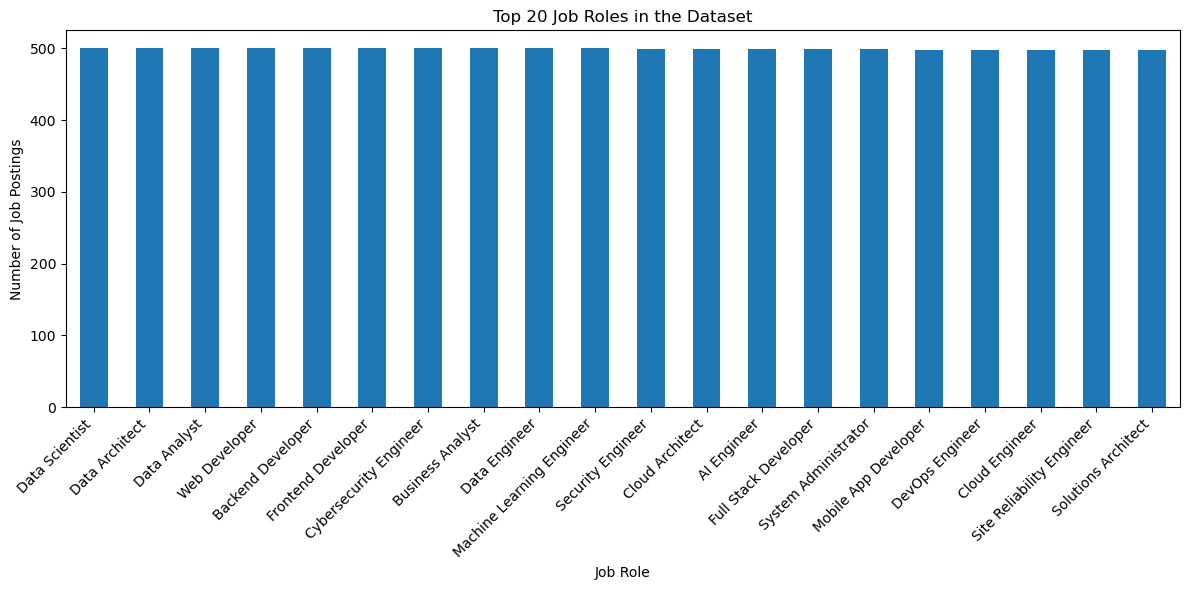

In [30]:
plt.figure(figsize=(12, 6))

role_counts.head(20).plot(kind="bar")

plt.title("Top 20 Job Roles in the Dataset")
plt.xlabel("Job Role")
plt.ylabel("Number of Job Postings")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [31]:
target_distribution = pd.DataFrame({
    "Count": df["search_role"].value_counts(),
    "Percentage": (
        df["search_role"].value_counts(normalize=True) * 100
    ).round(2)
})

target_distribution

,Count,Percentage
search_role,,
Data Scientist,500,4.13
Data Architect,500,4.13
Data Analyst,500,4.13
Web Developer,500,4.13
Backend Developer,500,4.13
Frontend Developer,500,4.13
Cybersecurity Engineer,500,4.13
Business Analyst,500,4.13
Data Engineer,500,4.13


In [32]:
target_distribution = pd.DataFrame({
    "Count": df["search_role"].value_counts(),
    "Percentage": (
        df["search_role"].value_counts(normalize=True) * 100
    ).round(2)
})

target_distribution

,Count,Percentage
search_role,,
Data Scientist,500,4.13
Data Architect,500,4.13
Data Analyst,500,4.13
Web Developer,500,4.13
Backend Developer,500,4.13
Frontend Developer,500,4.13
Cybersecurity Engineer,500,4.13
Business Analyst,500,4.13
Data Engineer,500,4.13


In [33]:
print("Unique job titles:", df["job_title"].nunique())

df["job_title"].value_counts().head(20)

Unique job titles: 4446


job_title
Frontend Developer           438
DevOps Engineer              379
Backend Developer            375
Business Analyst             356
Full Stack Developer         351
Web Developer                280
Software Developer           274
Data Analyst                 229
Data Scientist               219
AI Engineer                  155
Solution Architect           145
Software Engineer            128
Data Engineer                128
Senior Data Engineer         127
Data Architect               123
Machine Learning Engineer     92
Devops Engineer               81
Site Reliability Engineer     77
Senior AI Engineer            68
Cloud Platform Engineer       67
Name: count, dtype: int64

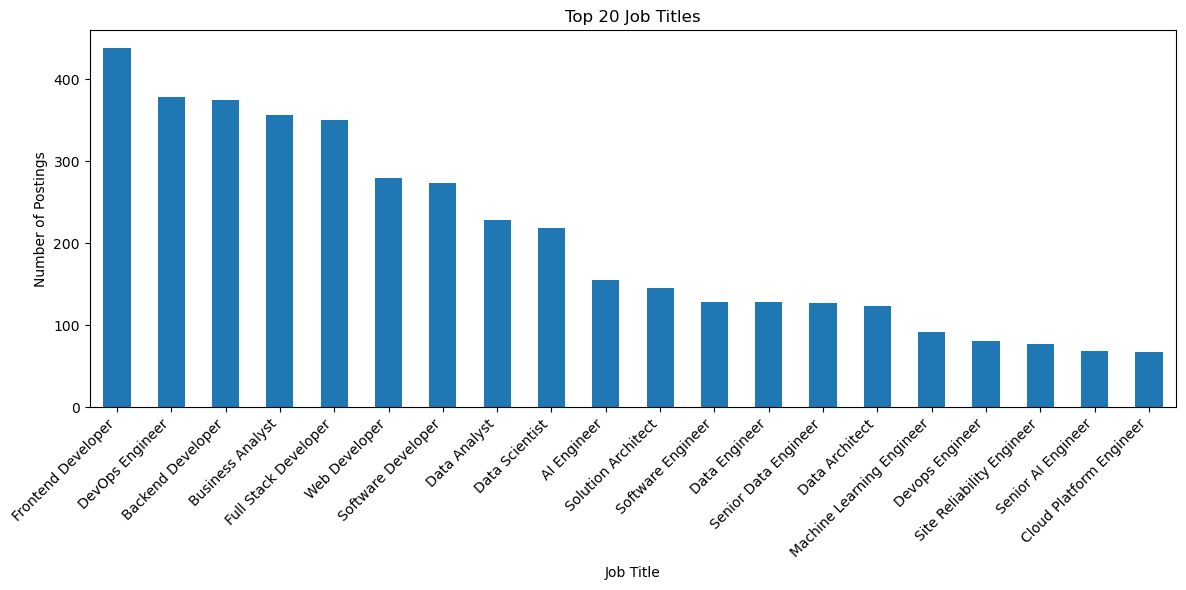

In [34]:
plt.figure(figsize=(12, 6))

df["job_title"].value_counts().head(20).plot(kind="bar")

plt.title("Top 20 Job Titles")
plt.xlabel("Job Title")
plt.ylabel("Number of Postings")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [35]:
print("Unique locations:", df["location"].nunique())

df["location"].value_counts().head(20)

Unique locations: 192


location
India                       3610
Bangalore, Karnataka        3063
Hyderabad, Telangana        1199
Pune, Maharashtra            727
Mumbai, Maharashtra          716
Chennai, Tamil Nadu          667
Noida, Ghaziabad             348
Delhi, India                 312
Ahmedabad, Gujarat           158
Kolkata, West Bengal         125
Gurgaon, Haryana             118
Jaipur, Rajasthan             73
Navi Mumbai, Maharashtra      70
Coimbatore, Tamil Nadu        68
Kochi, Ernakulam              61
Indore, Madhya Pradesh        52
Vadodara, Gujarat             40
Mohali, Punjab                34
Kyasaram, Hyderabad           27
Nagpur, Maharashtra           24
Name: count, dtype: int64

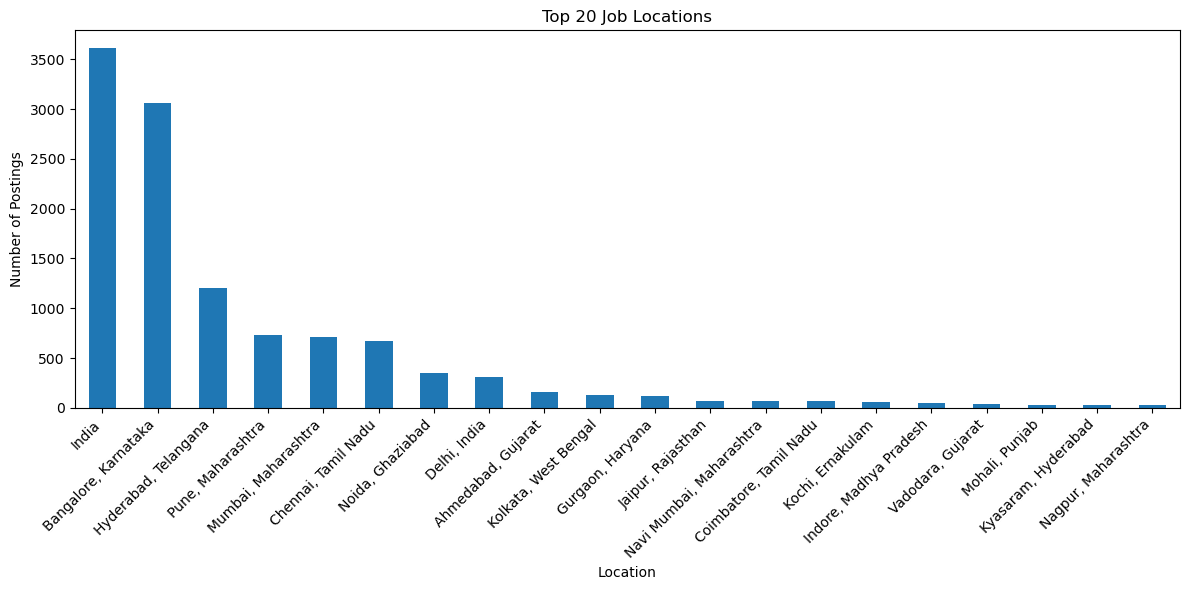

In [36]:
plt.figure(figsize=(12, 6))

df["location"].value_counts().head(20).plot(kind="bar")

plt.title("Top 20 Job Locations")
plt.xlabel("Location")
plt.ylabel("Number of Postings")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [37]:
print("Unique companies:", df["company"].nunique())

df["company"].value_counts().head(20)

Unique companies: 4693


company
Accenture                    487
Tata Consultancy Services    300
Kyndryl                      222
EXL                          107
Amazon                        85
Infosys Limited               84
Qrata                         83
Capco                         81
Amgen                         66
Jobdost                       64
PricewaterhouseCoopers        57
HP                            52
Persistent Systems            52
NTT America, Inc.             51
Cornerstone OnDemand          48
Multi Recruit                 46
Deutsche Bank                 45
Tiger Analytics               45
Warner Bros. Discovery        44
Cisco                         43
Name: count, dtype: int64

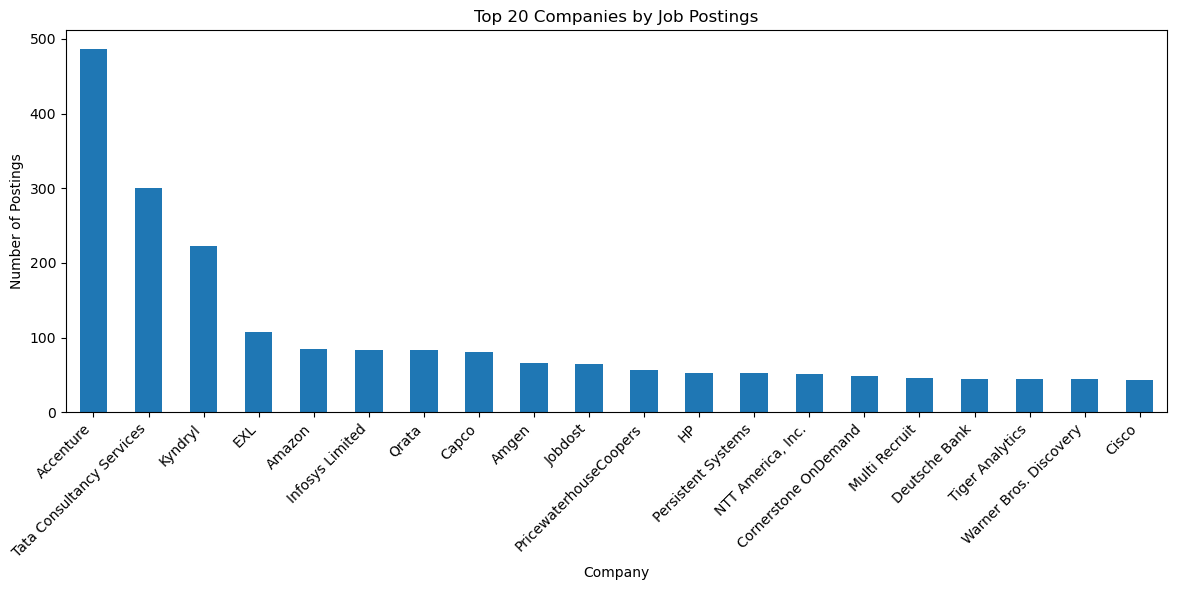

In [38]:
plt.figure(figsize=(12, 6))

df["company"].value_counts().head(20).plot(kind="bar")

plt.title("Top 20 Companies by Job Postings")
plt.xlabel("Company")
plt.ylabel("Number of Postings")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [39]:
df["created"] = pd.to_datetime(
    df["created"],
    errors="coerce"
)

print(df["created"].dtype)

datetime64[ns, UTC]


In [40]:
print("Earliest posting:", df["created"].min())
print("Latest posting:", df["created"].max())

Earliest posting: 2019-05-17 21:02:37+00:00
Latest posting: 2026-09-16 07:54:21+00:00


In [41]:
monthly_jobs = (
    df["created"]
    .dt.to_period("M")
    .value_counts()
    .sort_index()
)

monthly_jobs

/var/folders/d1/dh2cqpn53q78qb4gs2ydj0rr0000gn/T/ipykernel_4933/3372262206.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  .dt.to_period("M")


created
2019-05      85
2019-06     220
2019-07       7
2019-08      23
2019-09      11
           ... 
2026-05     358
2026-06     427
2026-07     929
2026-08    2801
2026-09    3822
Freq: M, Name: count, Length: 89, dtype: int64

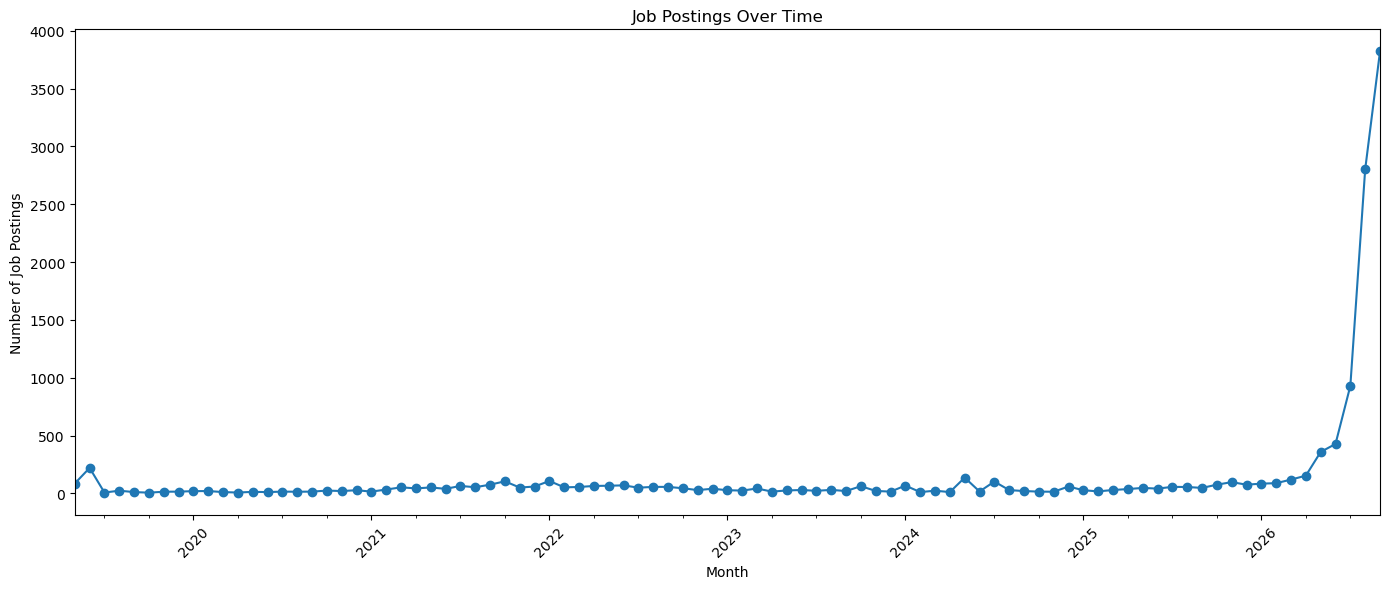

In [42]:
plt.figure(figsize=(14, 6))

monthly_jobs.plot(kind="line", marker="o")

plt.title("Job Postings Over Time")
plt.xlabel("Month")
plt.ylabel("Number of Job Postings")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [43]:
print("Missing descriptions:", df["description"].isnull().sum())
print(
    "Missing description percentage:",
    round(df["description"].isnull().mean() * 100, 2),
    "%"
)

Missing descriptions: 0
Missing description percentage: 0.0 %


In [44]:
df["description_length"] = (
    df["description"]
    .fillna("")
    .astype(str)
    .str.len()
)

df["description_word_count"] = (
    df["description"]
    .fillna("")
    .astype(str)
    .str.split()
    .str.len()
)

In [45]:
df[
    ["description_length", "description_word_count"]
].describe()

,description_length,description_word_count
count,12119.000000,12119.000000
mean,492.346728,71.260335
std,41.728271,8.742769
min,100.000000,13.000000
25%,500.000000,67.000000
50%,500.000000,72.000000
75%,500.000000,76.000000
max,500.000000,126.000000


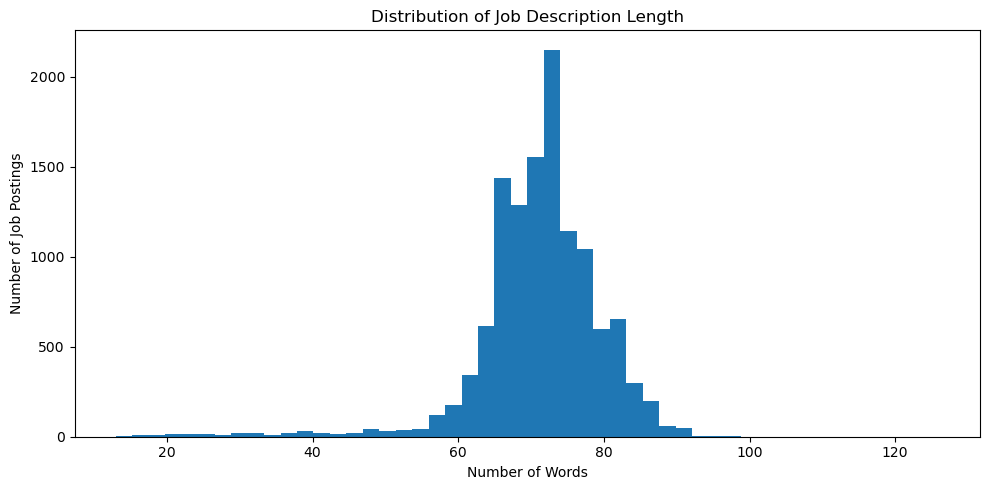

In [46]:
plt.figure(figsize=(10, 5))

plt.hist(
    df["description_word_count"],
    bins=50
)

plt.title("Distribution of Job Description Length")
plt.xlabel("Number of Words")
plt.ylabel("Number of Job Postings")
plt.tight_layout()
plt.show()

In [47]:
df["job_title"] = (
    df["job_title"]
    .fillna("Unknown")
    .astype(str)
    .str.strip()
)

In [48]:
df["company"] = (
    df["company"]
    .fillna("Unknown")
    .astype(str)
    .str.strip()
)

In [49]:
df["location"] = (
    df["location"]
    .fillna("Unknown")
    .astype(str)
    .str.strip()
)

In [50]:
df["description"] = (
    df["description"]
    .fillna("")
    .astype(str)
    .str.strip()
)

In [51]:
df["search_role"] = (
    df["search_role"]
    .fillna("Unknown")
    .astype(str)
    .str.strip()
)

In [52]:
df["job_text"] = (
    df["job_title"] + " " +
    df["description"] + " " +
    df["company"] + " " +
    df["location"]
)

In [53]:
df[[
    "job_title",
    "company",
    "location",
    "description",
    "job_text",
    "search_role"
]].head(3)

,job_title,company,location,description,job_text,search_role
0,Data Scientist,EXL,India,"Advanced Analytics & Data Science Execution: Lead high-impact AI and data science projects, incl...",Data Scientist Advanced Analytics & Data Science Execution: Lead high-impact AI and data science...,Data Scientist
1,Data Scientist,Infosys Finacle,"Bangalore, Karnataka",Job Title: Data Scientist and Senior Data Scientist / AI & Machine Learning Engineer Experience ...,Data Scientist Job Title: Data Scientist and Senior Data Scientist / AI & Machine Learning Engin...,Data Scientist
2,Data Scientist,Tata Consultancy Services,"Bangalore, Karnataka",TCS has been a great pioneer in feeding the fire of Young Techies like you. We are a global lead...,Data Scientist TCS has been a great pioneer in feeding the fire of Young Techies like you. We ar...,Data Scientist


In [54]:
df["created_year"] = df["created"].dt.year
df["created_month"] = df["created"].dt.month
df["created_day"] = df["created"].dt.day

In [55]:
df = df.drop(columns=["created"])

In [56]:
print("Final shape:", df.shape)

df.info()

Final shape: (12119, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12119 entries, 0 to 12118
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   job_title               12119 non-null  object
 1   company                 12119 non-null  object
 2   location                12119 non-null  object
 3   description             12119 non-null  object
 4   search_role             12119 non-null  object
 5   description_length      12119 non-null  int64 
 6   description_word_count  12119 non-null  int64 
 7   job_text                12119 non-null  object
 8   created_year            12119 non-null  int32 
 9   created_month           12119 non-null  int32 
 10  created_day             12119 non-null  int32 
dtypes: int32(3), int64(2), object(6)
memory usage: 899.6+ KB


In [57]:
df.isnull().sum()

job_title                 0
company                   0
location                  0
description               0
search_role               0
description_length        0
description_word_count    0
job_text                  0
created_year              0
created_month             0
created_day               0
dtype: int64

In [58]:
df.head()

,job_title,company,location,description,search_role,description_length,description_word_count,job_text,created_year,created_month,created_day
0,Data Scientist,EXL,India,"Advanced Analytics & Data Science Execution: Lead high-impact AI and data science projects, incl...",Data Scientist,500,64,Data Scientist Advanced Analytics & Data Science Execution: Lead high-impact AI and data science...,2026,9,2
1,Data Scientist,Infosys Finacle,"Bangalore, Karnataka",Job Title: Data Scientist and Senior Data Scientist / AI & Machine Learning Engineer Experience ...,Data Scientist,500,81,Data Scientist Job Title: Data Scientist and Senior Data Scientist / AI & Machine Learning Engin...,2026,9,9
2,Data Scientist,Tata Consultancy Services,"Bangalore, Karnataka",TCS has been a great pioneer in feeding the fire of Young Techies like you. We are a global lead...,Data Scientist,500,87,Data Scientist TCS has been a great pioneer in feeding the fire of Young Techies like you. We ar...,2026,9,4
3,Data Scientist,Atain,India,Data Scientist Location: Remote – India Experience: 7 Years Employment Type: Full-Time Role Over...,Data Scientist,500,74,Data Scientist Data Scientist Location: Remote – India Experience: 7 Years Employment Type: Full...,2026,9,1
4,Data Scientist,AB InBev GCC India,"Bangalore, Karnataka",Dreaming big is in our DNA. It’s who we are as a company. It’s our culture. It’s our heritage. A...,Data Scientist,500,88,Data Scientist Dreaming big is in our DNA. It’s who we are as a company. It’s our culture. It’s ...,2026,9,1


In [59]:
df.to_csv("cleaned_jobs.csv", index=False)